In [153]:
import numpy as np
import matplotlib.pyplot as plt
import math  # Necesario para tu script
from scipy.optimize import differential_evolution
from scipy.constants import (
    k as Boltzmann,
    elementary_charge,
    epsilon_0,
)  # Alias para usar tus nombres
import os


In [154]:
# =============================================================================
# 1. BLOQUE DE CONFIGURACIÓN
# =============================================================================

# Nombre de tu archivo de datos (Columna 1: Voltaje, Columna 2: Corriente)
ARCHIVO_DATOS = "C:/Users/Usuario/Documents/GitHub/RRAM_Simulation/Datos_Experimentales/Ciclos_Experimentales/Cycle_n_sp_1000.txt"

# Parámetros Fijos del Sistema
ESPESOR_MUESTRA = 10e-9  # m
T_INICIAL = 800 #310.00090159977754  # Kelvin (T0)
R_TERMICA = 100000  # K/W (Valor fijo de resistencia térmica)

# Configuración del Algoritmo Genético (Límites de búsqueda)
# Formato: (mínimo, máximo)
LIMITES = [
    (0.005, 300.0),  # 1. Epsilon_r (Permitividad relativa)
    (0.001, 2.0),  # 2. Barrera de Potencial (eV)
    (1e-7, 1e-0),  # 3. Factor de Escala (Pre-factor)
]

# =============================================================================
# 2. CONSTANTES FÍSICAS Y MATEMÁTICAS
# =============================================================================

# Constante de Boltzmann en eV/K (~8.617e-5)
K_B_EV = Boltzmann / elementary_charge

In [155]:
# =============================================================================
# 2. MODELO SECUENCIAL DIRECTO (SIN BUCLES INTERNOS)
# =============================================================================

def simular_curva_directa(
    voltajes, epsilon_r, barrier_eV, scale_factor, t_start=T_INICIAL
):
    """
    Calcula la curva I-V usando TU script para Beta y k_b_ev.
    """
    corrientes_out = []
    temperaturas_out = []

    # --- TU SCRIPT DE CONSTANTES ---
    # Convertimos la constante de Boltzmann a eV/K
    k_b_ev = Boltzmann / elementary_charge

    # Calculamos Beta usando tu fórmula exacta
    # Nota: epsilon_r es el parámetro que el algoritmo va cambiando
    beta = math.sqrt(elementary_charge / (epsilon_0 * epsilon_r * math.pi))

    # -------------------------------

    # Temperatura inicial
    T_previo = t_start

    for v in voltajes:
        V_mag = abs(v)

        if V_mag == 0:
            corrientes_out.append(0.0)
            temperaturas_out.append(T_INICIAL)
            T_previo = T_INICIAL
            continue

        # 1. CÁLCULO DE CORRIENTE
        E_field = V_mag / ESPESOR_MUESTRA

        # Poole-Frenkel Effect
        # beta * sqrt(E) tiene unidades de energía (eV) gracias a tu fórmula
        barrier_lowering = beta * math.sqrt(E_field)

        # Argumento exponencial: (Reducción - Barrera) / (K_B_EV * T)
        
        # Nota: Ajustamos signo para que I suba con el campo
        numerador = (barrier_lowering - barrier_eV)
        denominador = K_B_EV * T_previo

        # Protección numérica
        if denominador < 1e-10:
            denominador = 1e-10
        arg = numerador / denominador

        # Tope para evitar overflow (números infinitos)
        if arg > 100:
            arg = 100

        I_sim = scale_factor * E_field * math.exp(arg) * ESPESOR_MUESTRA

        # 2. CÁLCULO DE TEMPERATURA (Joule)
        potencia = V_mag * I_sim
        T_nueva = T_INICIAL + (potencia * R_TERMICA)

        corrientes_out.append(I_sim)
        temperaturas_out.append(T_nueva)

        # Actualizamos la temperatura para el siguiente punto del bucle
        T_previo = T_nueva

    return np.array(corrientes_out), np.array(temperaturas_out)


In [156]:
# =============================================================================
# 3. ALGORITMO GENÉTICO
# =============================================================================

def funcion_costo(genes, v_exp, i_exp_abs, t_inicial_estimada):
    eps, phi, scale = genes
    if eps < 1.0 or phi < 0.0 or scale <= 0.0: return 1e99
    
    # Pasamos la temperatura inicial a la simulación
    i_sim, _ = simular_curva_directa(v_exp, eps, phi, scale, t_start=t_inicial_estimada)
    
    mask = (i_exp_abs > 1e-25) & (i_sim > 1e-25)
    if np.sum(mask) == 0: return 1e99
    
    return np.sqrt(np.mean((np.log10(i_exp_abs[mask]) - np.log10(i_sim[mask]))**2))

print("Modelo actualizado con Temperatura Inicial.")

def costo_hibrido(genes, v_exp, i_exp_abs, t_start):
    eps, phi, scale = genes
    if eps < 1.0 or phi < 0.0 or scale <= 0.0:
        return 1e99

    i_sim, _ = simular_curva_directa(v_exp, eps, phi, scale, t_start=t_start)

    mask = (i_exp_abs > 1e-25) & (i_sim > 1e-25)
    if np.sum(mask) < 5:
        return 1e99  # Necesitamos mínimos puntos para derivada

    log_exp = np.log(i_exp_abs[mask])
    log_sim = np.log(i_sim[mask])

    # 1. Error de Magnitud (RMSE clásico)
    mse_val = np.mean((log_exp - log_sim) ** 2)

    # 2. Error de Pendiente (Derivada)
    # Calculamos cómo cambia la corriente respecto al voltaje (la forma de la curva)
    grad_exp = np.gradient(log_exp)
    grad_sim = np.gradient(log_sim)

    mse_grad = np.mean((grad_exp - grad_sim) ** 2)

    # Combinamos ambos errores
    # Le damos mucho peso a la pendiente (x10) para forzar la física correcta
    costo_total = mse_val + (10.0 * mse_grad)

    return costo_total

Modelo actualizado con Temperatura Inicial.


In [157]:
print("--- AJUSTE CON VALORES INICIALES ---")

# EL archivo de datos txt
ruta_datos = os.path.join(ARCHIVO_DATOS)
datos = np.loadtxt(ruta_datos, skiprows=1)

print(f"Cargando datos desde: {ruta_datos}")

V_exp = datos[:, 0]
I_exp = datos[:, 1]
I_exp_abs = np.abs(I_exp)

V_inicial = abs(V_exp[0])
I_inicial = I_exp_abs[0]

print(f"Voltaje inicial: {V_inicial} V")
print(f"Corriente inicial: {I_inicial:.2e} A")
print(f"Temperatura inicial estimada para el ajuste: {T_INICIAL:.10f} K")


--- AJUSTE CON VALORES INICIALES ---
Cargando datos desde: C:/Users/Usuario/Documents/GitHub/RRAM_Simulation/Datos_Experimentales/Ciclos_Experimentales/Cycle_n_sp_1000.txt
Voltaje inicial: 1.38 V
Corriente inicial: 6.53e-03 A
Temperatura inicial estimada para el ajuste: 800.0000000000 K


differential_evolution step 1: f(x)= 2.2170196868306933
differential_evolution step 2: f(x)= 0.5860884879381068
differential_evolution step 3: f(x)= 0.3004807241857097
differential_evolution step 4: f(x)= 0.10702314248618883
differential_evolution step 5: f(x)= 0.08580752099632916
differential_evolution step 6: f(x)= 0.08580752099632916
differential_evolution step 7: f(x)= 0.08081341623567005
differential_evolution step 8: f(x)= 0.0557369660300076
differential_evolution step 9: f(x)= 0.0557369660300076
differential_evolution step 10: f(x)= 0.02233169338953183
differential_evolution step 11: f(x)= 0.012802846547799944
differential_evolution step 12: f(x)= 0.012802846547799944
differential_evolution step 13: f(x)= 0.01179646834899531
differential_evolution step 14: f(x)= 0.010297024906456516
differential_evolution step 15: f(x)= 0.010297024906456516
differential_evolution step 16: f(x)= 0.010297024906456516
differential_evolution step 17: f(x)= 0.010253531675752096
differential_evolution

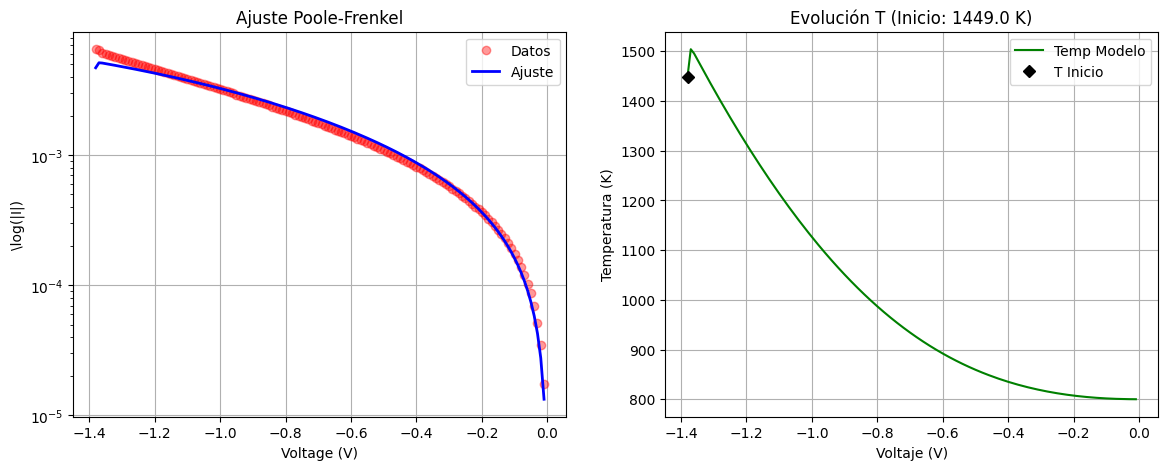

In [158]:
# 2. EJECUTAR AJUSTE
resultado = differential_evolution(
    costo_hibrido,
    bounds=LIMITES,
    # Pasamos la T calculada como argumento extra ('args')
    args=(V_exp, I_exp_abs, T_INICIAL),
    strategy="best1bin",
    popsize=20,
    maxiter=15000,
    disp=True,
)

# 3. RESULTADOS
best_eps, best_phi, best_scale = resultado.x
print("\n" + "=" * 40)
print(f"Epsilon_r: {best_eps:.4f}")
print(f"Barrera:   {best_phi:.4f} eV")
print(f"I_0:    {best_scale:.4e}")
print("=" * 40)

# 4. GRAFICAR
# Importante: Al graficar, también debemos usar esa T_start
I_fit, T_fit = simular_curva_directa(
    V_exp, best_eps, best_phi, best_scale, t_start=T_INICIAL
)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot Poole-Frenkel

ax1.plot(V_exp, I_exp_abs, "ro", alpha=0.4, label="Datos")
ax1.plot(V_exp, I_fit, "b-", linewidth=2, label="Ajuste")
ax1.set_yscale("log")
ax1.set_xlabel(r"Voltage (V)")
ax1.set_ylabel(r"\log(|I|)")
ax1.set_title("Ajuste Poole-Frenkel")
ax1.legend()
ax1.grid(True)

# Plot Temperatura
ax2.plot(V_exp, T_fit, "g-", label="Temp Modelo")
# Marcamos el punto de inicio
ax2.plot(V_exp[0], T_fit[0], "kD", label="T Inicio")
ax2.set_xlabel("Voltaje (V)")
ax2.set_ylabel("Temperatura (K)")
ax2.set_title(f"Evolución T (Inicio: {T_fit[0]:.1f} K)")
ax2.legend()
ax2.grid(True)

plt.show()
